In [1]:
import pandas as pd
import numpy as np

In [2]:
df_2024_1 = pd.read_csv('ca-2024-01.csv', sep=';', decimal=',')
df_2024_2 = pd.read_csv('ca-2024-02.csv', sep=';', decimal=',')
df_2025_1 = pd.read_csv('ca-2025-01.csv', sep=';', decimal=',')
df_2025_2 = pd.read_csv('ca-2025-02.csv', sep=';', decimal=',')
df = pd.concat([df_2024_1, df_2024_2, df_2025_1, df_2025_2], ignore_index=True)
df

C:\Users\daniel.cnunes.SENACRJEDU\AppData\Local\Temp\ipykernel_30504\4038111859.py:3: DtypeWarning: Columns (0: Regiao - Sigla, 1: Estado - Sigla, 2: Municipio, 3: Revenda, 4: CNPJ da Revenda, 5: Nome da Rua, 6: Numero Rua, 7: Complemento, 8: Bairro, 9: Cep, 10: Produto, 11: Data da Coleta, 12: Unidade de Medida, 13: Bandeira) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2025_1 = pd.read_csv('ca-2025-01.csv', sep=';', decimal=',')


,Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira
0,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
1,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,GASOLINA ADITIVADA,01/01/2024,5.68,NaN,R$ / litro,VIBRA
2,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,DIESEL S10,01/01/2024,5.93,NaN,R$ / litro,VIBRA
3,NE,AL,ARAPIRACA,COMERCIAL DE COMBUSTIVEIS E LUBRIFICANTES VITA...,02.817.655/0001-82,RODOVIA AL-220,1901,NaN,SANTA ESMERALDA,57312-025,ETANOL,01/01/2024,3.99,NaN,R$ / litro,VIBRA
4,NE,AL,ARAPIRACA,AUTO POSTO SAO FRANCISCO LTDA,12.706.529/0001-04,RUA SAO FRANCISCO,274,NaN,CENTRO,57300-080,GASOLINA,01/01/2024,5.48,NaN,R$ / litro,VIBRA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712262,NE,BA,ALAGOINHAS,2 A COMERCIO DE COMBUSTIVEIS GNV E LUBRIFICANT...,14238511000150,RODOVIA BR 101 KM 116,S/N,SALA 01,CENTRO,48005-440,GNV,31/12/2025,4.38,NaN,R$ / m3,LARCO
1712263,NE,PB,BAYEUX,PETROGAS COMERCIO DE COMBUSTIVEIS LTDA,21553439000111,AVENIDA LIBERDADE,3545,ANDAR: 1; ANEXO: A;,SESI,58306-000,GNV,31/12/2025,4.85,NaN,R$ / m3,ALE
1712264,NE,BA,ILHEUS,BATISTA COMERCIO DE COMBUSTIVEIS E LUBRIFICANT...,28562491000183,AVENIDA FERROVIARIA,S/N,KM 05 RODOVIA ILHEUS,IGUAPE,45658-340,GNV,31/12/2025,4.73,NaN,R$ / m3,BRANCA
1712265,SE,SP,JACAREI,AUTO POSTO BRANCO DE CASTELO LTDA,68912864000385,AVENIDA SIQUEIRA CAMPOS,641,NaN,CENTRO,12308-190,GNV,31/12/2025,3.99,NaN,R$ / m3,VIBRA


In [37]:
df_bairro_gas = df.loc[(df['Municipio'] == 'RIO DE JANEIRO') & (df['Produto'] == 'GASOLINA')]

df_munic_gas_rj = (df_bairro_gas.groupby('Bairro')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False))

array_munic_rj = np.array(df_munic_gas_rj['Valor de Venda'])

minimo = np.min(array_munic_rj)
maximo = np.max(array_munic_rj)
aplitude = maximo - minimo
media = np.mean(array_munic_rj)
mediana = np.median(array_munic_rj)
q1 = np.percentile(array_munic_rj, 25)
q2 = np.percentile(array_munic_rj, 50)
q3 = np.percentile(array_munic_rj, 75)
distancia = (media - mediana) / mediana
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

In [4]:
print(f'Média {media}')
print(f'Médiana {mediana}')
print(f'Q1 {q1}')
print(f'Q2 {q2}')
print(f'Q3 {q3}')
print(f'Distância {distancia:.2%}')
print(f'Limite superior {limite_superior}')
print(f'Limite inferior {limite_inferior}')

Média 5.854678797322661
Médiana 5.8434
Q1 5.640000000000001
Q2 5.8434
Q3 6.060588235294118
Distância 0.19%
Limite superior 6.691470588235293
Limite inferior 5.009117647058825


In [ ]:
outlier_sup = df_munic_gas_rj.loc[df_munic_gas_rj['Valor de Venda'] > limite_superior]
outlier_inf = df_munic_gas_rj.loc[df_munic_gas_rj['Valor de Venda'] < limite_inferior]
outlier_sup = outlier_sup.sort_values(by='Valor de Venda', ascending=False)
outlier_inf = outlier_inf.sort_values(by='Valor de Venda', ascending=True)

display(outlier_sup)
display(outlier_inf)

In [ ]:
outlier_sup

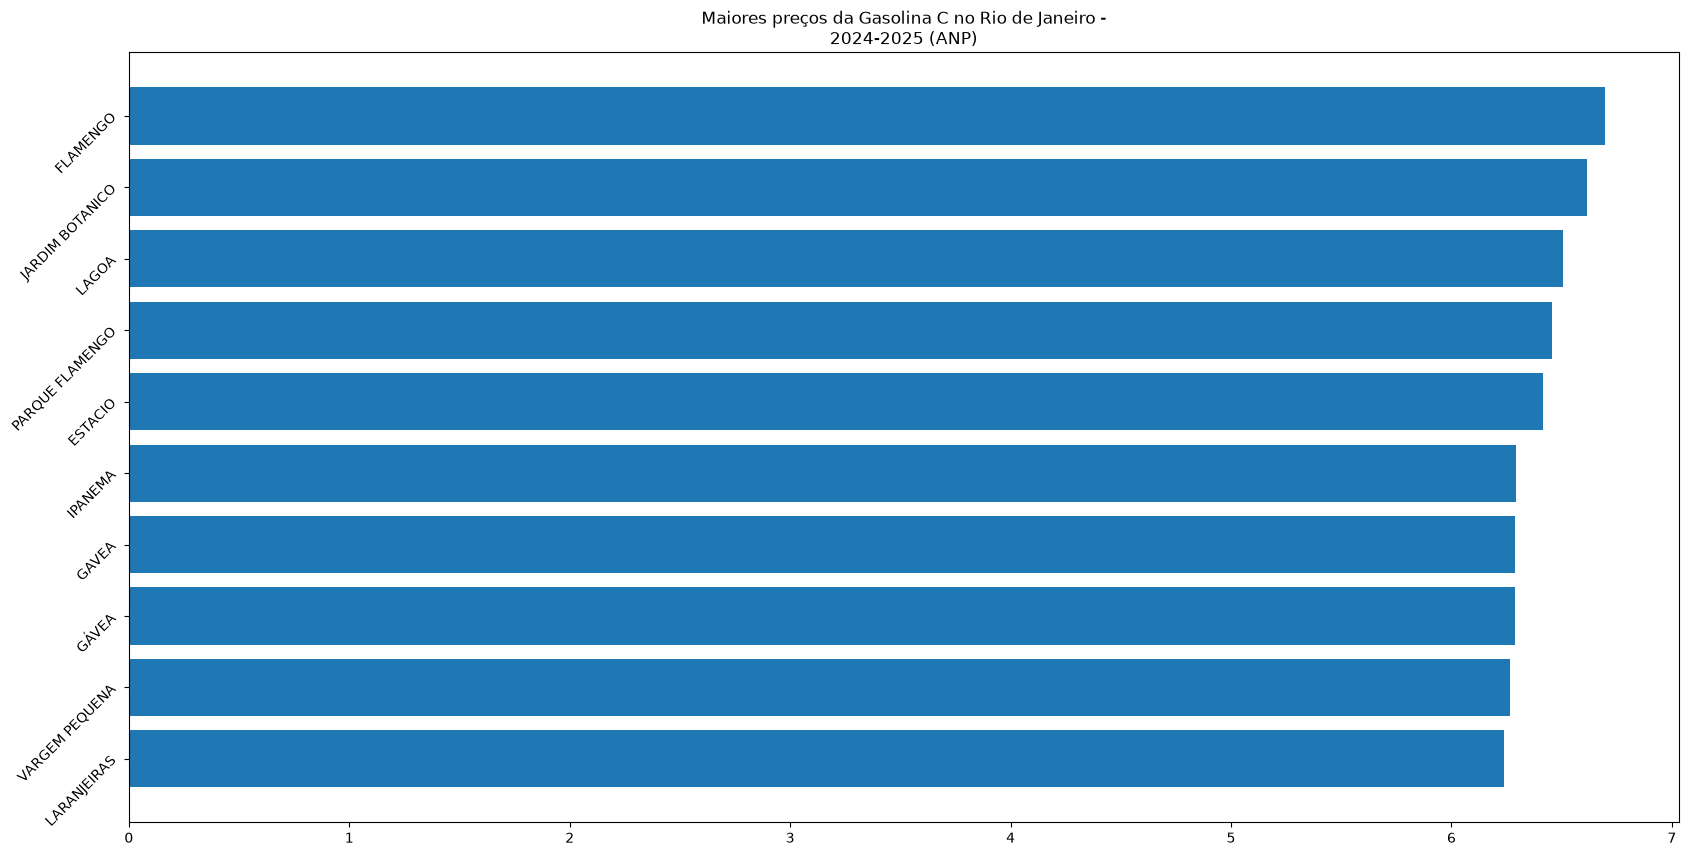

In [35]:
import matplotlib.pyplot as plt

df_munic_gas_rj = df_munic_gas_rj.head(10)
gas_maior = df_munic_gas_rj.sort_values(by='Valor de Venda', ascending=True)
plt.figure(figsize=(20,10))
plt.barh(gas_maior['Bairro'], gas_maior['Valor de Venda'])
plt.yticks(rotation=45)
plt.title('Maiores preços da Gasolina C no Rio de Janeiro -\n2024-2025 (ANP)')

plt.show()

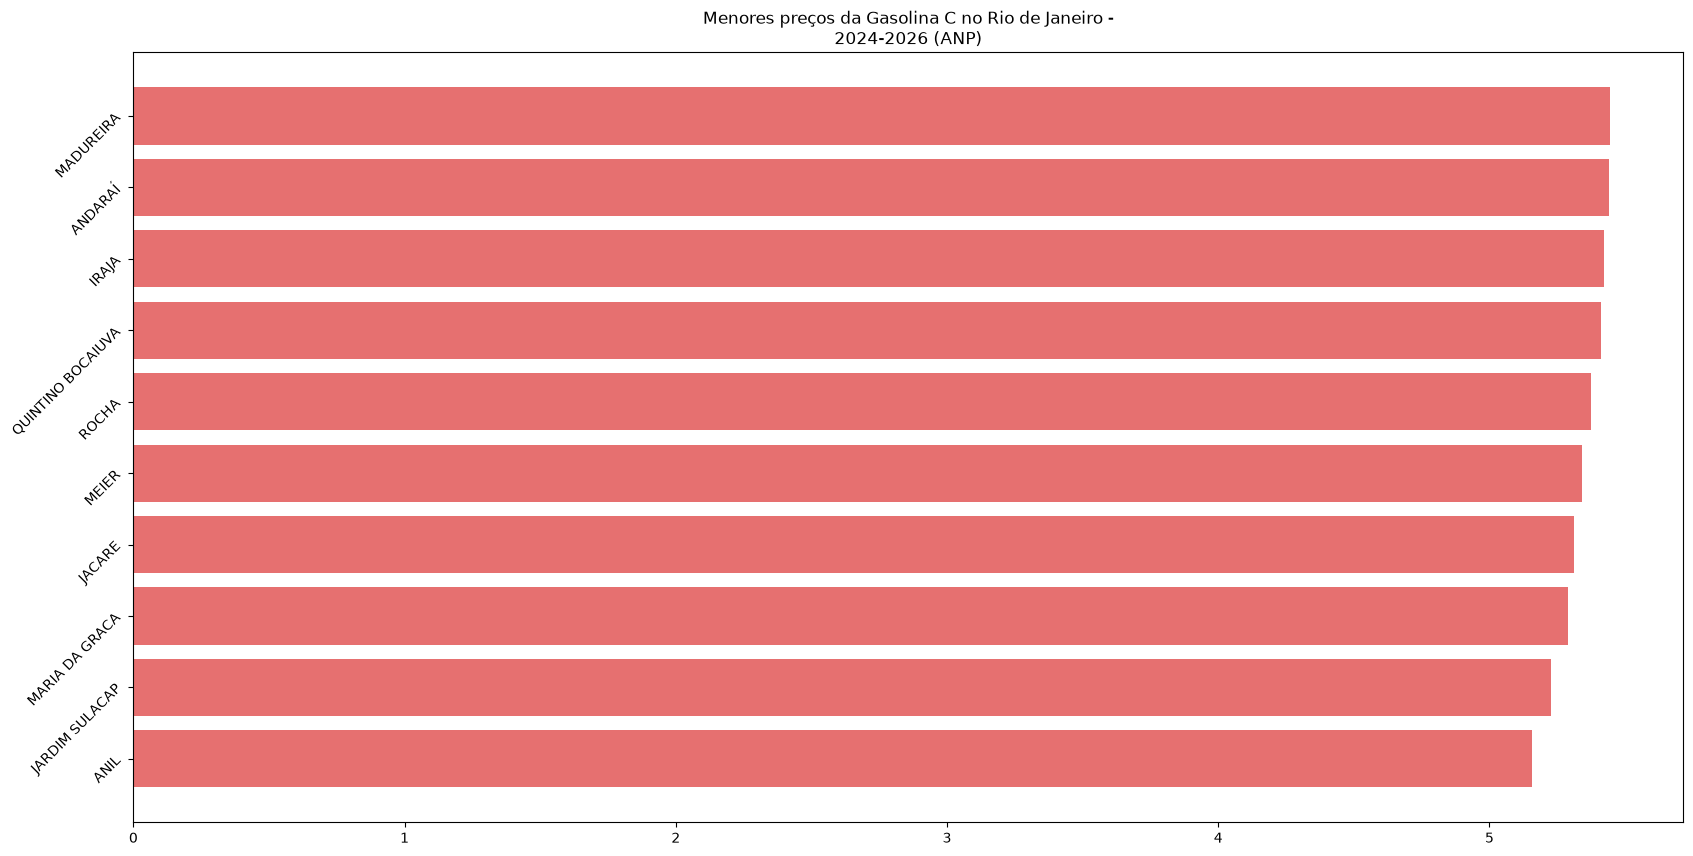

In [40]:
df_munic_gas_rj = df_munic_gas_rj.tail(10)
gas_menor = df_munic_gas_rj.sort_values(by='Valor de Venda', ascending=True)
plt.figure(figsize=(20,10))
plt.barh(gas_menor['Bairro'], gas_menor['Valor de Venda'], color='#e67070')
plt.yticks(rotation=45)
plt.title('Menores preços da Gasolina C no Rio de Janeiro -\n2024-2026 (ANP)')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.boxplot(array_munic_rj, orientation='horizontal', showmeans=True)
plt.show

In [ ]:
df_gas_tempo = df.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)

df_gas_tempo

In [ ]:
df_gas_tempo['Data da Coleta'] = pd.to_datetime(df_gas_tempo['Data da Coleta'], dayfirst=True)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plt.plot(df_gas_tempo['Valor de Venda'],
         df_gas_tempo['Data da Coleta'], marker='o')
plt.title('Preço médio da Gasolina C -\n2024-2026 (ANP)')
plt.show()

In [ ]:
df_preco_gas = df.groupby('Data da Coleta')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)
df_preco_gas['Data da Coleta'] = pd.to_datetime(df_preco_gas['Data da Coleta'], dayfirst=True)

array_preco_gas = np.array(df_preco_gas['Valor de Venda'])

minimo = np.min(array_preco_gas)
maximo = np.max(array_preco_gas)
aplitude = maximo - minimo
media = np.mean(array_preco_gas)
mediana = np.median(array_preco_gas)
q1 = np.percentile(array_preco_gas, 25)
q2 = np.percentile(array_preco_gas, 50)
q3 = np.percentile(array_preco_gas, 75)
distancia = (media - mediana) / mediana
iqr = q3 - q1
limite_superior = q3 + (1.5 * iqr)
limite_inferior = q1 - (1.5 * iqr)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plt.bar(df_preco_gas['Data da Coleta'], df_preco_gas['Valor de Venda'])
plt.title('Preço médio da Gasolina por mês (ANP)')
plt.show

In [ ]:
df_rj_gas = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]

df_munic_gas_rj = (df_rj_gas.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False))
df_munic_gas_rj

In [ ]:
df_rj_gas = df.loc[(df['Estado - Sigla'] == 'RJ') & (df['Produto'] == 'GASOLINA')]
df_munic_gas_rj = df_rj_gas.groupby('Municipio')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False)

array_munic_gas = np.array(df_munic_gas_rj['Valor de Venda'])

media_munic_gas = np.mean(array_munic_gas)
mediana_munic_gas = np.median(array_munic_gas)
q1_venda = np.percentile(array_munic_gas, 25)
q3_venda = np.percentile(array_munic_gas, 75)
iqr = q3_venda - q1_venda
limite_superior = q3_venda + (1.5 * iqr)
limite_inferior = q1_venda - (1.5 * iqr)

outlier_sup = df_munic_gas_rj.loc[df_munic_gas_rj['Valor de Venda'] > limite_superior]
outlier_inf = df_munic_gas_rj.loc[df_munic_gas_rj['Valor de Venda'] < limite_inferior]
outlier_sup = outlier_sup.sort_values(by='Valor de Venda', ascending=False)
outlier_inf = outlier_inf.sort_values(by='Valor de Venda', ascending=True)

display(outlier_sup)
display(outlier_inf)

In [ ]:
limite_inferior

In [ ]:
limite_superior

In [ ]:
df_munic_gas_rj

In [ ]:
df_estados_gas = df.loc[(df['Estado - Sigla'].isin(['RJ', 'SP'])) & (df['Produto'] == 'ETANOL')]
df_rjsp_gas = (df_estados_gas.groupby('Estado - Sigla')['Valor de Venda'].mean().reset_index().sort_values(by='Valor de Venda', ascending=False))

array_estados_gas = np.array(df_rjsp_gas['Valor de Venda'])

q1_estados = np.percentile(array_estados_gas, 25)
q3_estados = np.percentile(array_estados_gas, 75)

iqr = q3_estados - q1_estados
limite_superior = q3_estados + (1.5 * iqr)
limite_inferior = q1_estados - (1.5 * iqr)

outlier_sup_estados = df_rjsp_gas.loc[df_rjsp_gas['Valor de Venda'] > limite_superior]
outlier_inf_estados = df_rjsp_gas.loc[df_rjsp_gas['Valor de Venda'] < limite_inferior]
outlier_sup_estados = outlier_sup_estados.sort_values(by='Valor de Venda', ascending=False)
outlier_inf_estados = outlier_inf_estados.sort_values(by='Valor de Venda', ascending=True)

display(outlier_sup_estados)
display(outlier_inf_estados)

In [ ]:
df_rj_bairros = df.loc[(df['Estado - Sigla'].isin(['RJ', 'SP'])) & (df['Produto'] == 'GASOLINA')]
df_bairros = (df_estados_gas.groupby('Bairro')['Valor de Venda'])